# Few-Shot Prompting on agnews

- total number of train samples: 0 (zero-shot), 1 or 2 per label
- total number of test&nbsp; samples: 500
- model: Casual LM
- dataset: agnews

TESTS:
- DeepSeek-R1-Distill-Qwen-1.5B
  1. zero-shot
  2. 1ex per label
  3. 2ex per label
- Llama-2-7b-hf  
  same...

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer, LlamaTokenizer, LlamaForCausalLM, BitsAndBytesConfig

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise
     
from src._utils._run_fewshotCasualLM import main_fewshot_classification
from src._utils._helpers import log_synthetic_data, response2json, get_response, set_seed, clear_cuda_cache, get_generated_examples_df

In [2]:
DATASET_NAME = "agnews"
FOLDER_DIR = "src/"+DATASET_NAME+"/experiments/fewshotCasualLM_500samples"
os.makedirs(FOLDER_DIR, exist_ok=True)
LOG_FILE = os.path.join(FOLDER_DIR, "fewshotCasualLM.json")
HF_TOKEN = open("src/_utils/hf_token.txt","r").read() # your huggingface token

### LOAD DATA ###
# real data
real_train_df = pd.read_csv("real_data/train/"+DATASET_NAME+"trainAll.csv").rename(columns={"2": "text", "3": "label"})
real_train_df.drop(columns=["0", "1"], inplace=True)

# Take 500 samples for dev set
real_train_df, dev_df = train_test_split(real_train_df, test_size=500, random_state=42, stratify=real_train_df["label"])
# Store the dev set into a CSV file
dev_df.to_csv(os.path.join(FOLDER_DIR, "dev_set.csv"), index=False)
# dev_df = pd.read_csv("src/agnews/experiments/RoBERTA_500samples/dev_set.csv")
model = None
results = []

In [3]:
def get_results(details):
    """Just get useful results from the details"""
    res = details["metrics_test"]
    model_method = details["output_file"].split("/")[-1].replace(".csv", "")
    res["model"] = model_method.split("_")[0]
    res["method"] = model_method.split("_")[1]
    res["eval_time"] = details["eval_time"]
    
    df = pd.DataFrame([res])
    new_order = ["model"] + ["method"] + [col for col in df.columns if col not in ["model", "method"]]
    df = df[new_order]
    display(df.round(3))
    return df

def get_n_examples_per_label(df, n):
    return df.groupby('label')[['text', 'label']].apply(
                lambda x: x.sample(n, random_state=42)
            ).reset_index(drop=True)

# take n examples per label
_1ex_perlabel = get_n_examples_per_label(real_train_df, 1)
_2ex_perlabel = get_n_examples_per_label(real_train_df, 2)

print("1 example per label")
display(_1ex_perlabel)
print("2 examples per label")
display(_2ex_perlabel)

instruction = "Classify the following texts into one of the given categories"
print("Instruction: ", instruction)

labels = real_train_df["label"].unique().tolist()
print("Labels: ", labels)


1 example per label


,text,label
0,WASHINGTON - The US job market brightened in A...,Business
1,AP - A U.S. Fish and Wildlife Service biologis...,Sci/Tech
2,Annika Sorenstam was hitting the ball so well ...,Sports
3,"Model Elizabeth Jagger, daughter of rocker Mic...",World


2 examples per label


,text,label
0,WASHINGTON - The US job market brightened in A...,Business
1,WASHINGTON - The nation will face quot;abrupt...,Business
2,AP - A U.S. Fish and Wildlife Service biologis...,Sci/Tech
3,"MONKEYS use tools to dig up roots, crack seeds...",Sci/Tech
4,Annika Sorenstam was hitting the ball so well ...,Sports
5,AP - Mark Knowles and Daniel Nestor won their ...,Sports
6,"Model Elizabeth Jagger, daughter of rocker Mic...",World
7,"Polio, which can paralyze small children, has ...",World


Instruction:  Classify the following texts into one of the given categories
Labels:  ['Sci/Tech', 'Sports', 'Business', 'World']



---
# DeepSeek-R1-Distill-Qwen-1.5B

In [5]:
if model:
    clear_cuda_cache(model)

model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
MODEL_NAME = "DeepSeek-R1-Distill-Qwen-1.5B"
quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    attn_implementation='flash_attention_2',
    quantization_config=quantization_config,
    low_cpu_mem_usage=True
).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model.generation_config.pad_token_id = tokenizer.pad_token_id


base_config = {
    "dataset_name": DATASET_NAME,
    "experiment_name": "fewshot_classification",
    # "fewshot_df": None /_1ex_perlabel..,
    "label": labels,
    "test_df": dev_df,
    "instruction": instruction,
    "model": model,
    "tokenizer": tokenizer,
    # "output_file": os.path.join(FOLDER_DIR, name),
    "log_file": LOG_FILE,
    "seed": 42,
    "verbose": False,
}

### 1. zero-shot

In [5]:
name = MODEL_NAME+"_zeroshot.csv"
config = base_config.copy()
config["fewshot_df"] = None
config["output_file"] = os.path.join(FOLDER_DIR, name)

details = main_fewshot_classification(config)
results.append(get_results(details))

Processing examples: 100%|██████████| 500/500 [01:07<00:00,  7.45it/s]


,model,method,f1_micro,f1_macro,accuracy,eval_time
0,DeepSeek-R1-Distill-Qwen-1.5B,zeroshot,0.046,0.014,0.046,67.118


In [6]:
df_res = pd.read_csv(config["output_file"])
display(df_res.head())

,text,label,predicted_label
0,"NEW DELHI, SEPTEMBER 17: The Cabinet today app...",World,?
1,In LONDON story headlined quot;Van Nistelrooy...,Sports,?
2,A new report from Congress #39; research arm a...,Business,?
3,The head of the U.N. nuclear watchdog agency s...,World,?
4,A years-long phenomenon continues as crowds ga...,Sci/Tech,World.


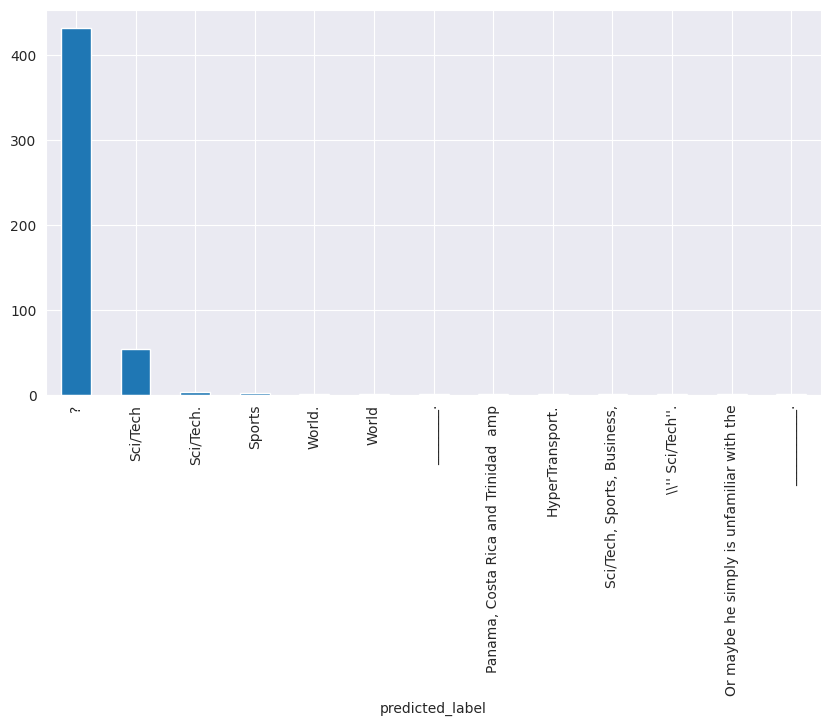

In [7]:
g = df_res["predicted_label"].value_counts().plot(kind="bar", figsize=(10, 5))

### 1B. zero-shot `\boxed{}`

In the documentation for deepseek we find: 
>>> For mathematical problems, it is advisable to include a directive in your prompt such as: "Please reason step by step, and put your final answer within \boxed{}."

Since this model is more adapt for reasoning, instead of a direct use as "plain" Language Model, we can try to ask the label in this specific format.

In [ ]:
name = MODEL_NAME+"_zeroshotBoxed.csv"
config = base_config.copy()
config["fewshot_df"] = None
config["output_file"] = os.path.join(FOLDER_DIR, name)
config["instruction"] = r"Classify the following texts into one of the given categories. Please reason step by step, and put your final answer within \boxed{}."
config["max_new_tokens"] = 256
config["boxed_label"] = True

details = main_fewshot_classification(config)
results.append(get_results(details))
results[0]

Processing examples:   0%|          | 0/500 [00:00<?, ?it/s]

Processing examples:   0%|          | 2/500 [00:23<1:38:41, 11.89s/it]


KeyboardInterrupt: 

### 2. 1ex per label

In [8]:
name = MODEL_NAME+"_1ex4label.csv"
config = base_config.copy()
config["fewshot_df"] = _1ex_perlabel
config["output_file"] = os.path.join(FOLDER_DIR, name)

details = main_fewshot_classification(config)
results.append(get_results(details))

Processing examples: 100%|██████████| 500/500 [01:10<00:00,  7.08it/s]


,model,method,f1_micro,f1_macro,accuracy,eval_time
0,DeepSeek-R1-Distill-Qwen-1.5B,1ex4label,0.44,0.302,0.44,70.612


### 3. 2ex per label

In [9]:
name = MODEL_NAME+"_2ex4label.csv"
config = base_config.copy()
config["fewshot_df"] = _2ex_perlabel
config["output_file"] = os.path.join(FOLDER_DIR, name)

details = main_fewshot_classification(config)
results.append(get_results(details))

Processing examples: 100%|██████████| 500/500 [01:17<00:00,  6.49it/s]


,model,method,f1_micro,f1_macro,accuracy,eval_time
0,DeepSeek-R1-Distill-Qwen-1.5B,2ex4label,0.482,0.47,0.482,77.06



---
# Llama-2-7b-hf

In [10]:
if model:
    clear_cuda_cache(model)

quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
model_name = "meta-llama/Llama-2-7b-hf"
MODEL_NAME = "Llama-2-7b-hf"
model = LlamaForCausalLM.from_pretrained(
            model_name, 
            token=HF_TOKEN,
            torch_dtype=torch.float16,
            attn_implementation='flash_attention_2',
            quantization_config=quantization_config,
            low_cpu_mem_usage=True
        ).to("cuda")

tokenizer = LlamaTokenizer.from_pretrained(model_name, token=HF_TOKEN)

base_config = {
    "dataset_name": DATASET_NAME,
    "experiment_name": "fewshot_classification",
    # "fewshot_df": None /_1ex_perlabel..,
    "label": labels,
    "test_df": dev_df,
    "instruction": instruction,
    "model": model,
    "tokenizer": tokenizer,
    # "output_file": os.path.join(FOLDER_DIR, name),
    "log_file": LOG_FILE,
    "seed": 42,
    "verbose": False,
}

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

### 1. zero-shot

In [11]:
name = MODEL_NAME+"_zeroshot.csv"
config = base_config.copy()
config["fewshot_df"] = None
config["output_file"] = os.path.join(FOLDER_DIR, name)

details = main_fewshot_classification(config)
results.append(get_results(details))

Processing examples: 100%|██████████| 500/500 [01:41<00:00,  4.94it/s]


,model,method,f1_micro,f1_macro,accuracy,eval_time
0,Llama-2-7b-hf,zeroshot,0.654,0.081,0.654,101.333


In [12]:
df_res = pd.read_csv(config["output_file"])
display(df_res.head())

,text,label,predicted_label
0,"NEW DELHI, SEPTEMBER 17: The Cabinet today app...",World,World
1,In LONDON story headlined quot;Van Nistelrooy...,Sports,World
2,A new report from Congress #39; research arm a...,Business,Business
3,The head of the U.N. nuclear watchdog agency s...,World,Sci/Tech
4,A years-long phenomenon continues as crowds ga...,Sci/Tech,Sci/Tech.


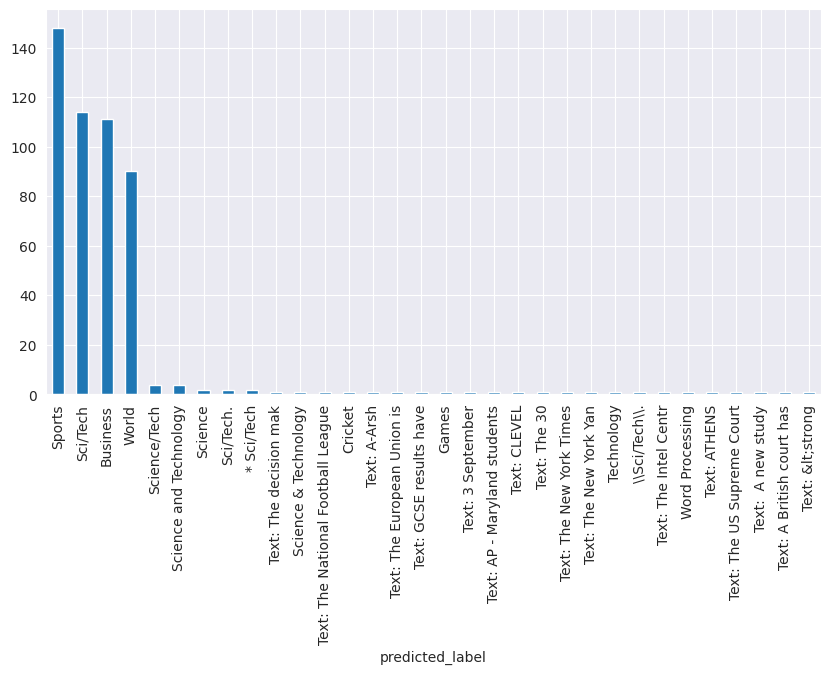

In [13]:
g = df_res["predicted_label"].value_counts().plot(kind="bar", figsize=(10, 5))

### 2. 1ex per label

In [14]:
name = MODEL_NAME+"_1ex4label.csv"
config = base_config.copy()
config["fewshot_df"] = _1ex_perlabel
config["output_file"] = os.path.join(FOLDER_DIR, name)

details = main_fewshot_classification(config)
results.append(get_results(details))

Processing examples:   0%|          | 0/500 [00:00<?, ?it/s]

Processing examples: 100%|██████████| 500/500 [02:01<00:00,  4.10it/s]


,model,method,f1_micro,f1_macro,accuracy,eval_time
0,Llama-2-7b-hf,1ex4label,0.69,0.535,0.69,121.847


### 3. 2ex per label

In [15]:
name = MODEL_NAME+"_2ex4label.csv"
config = base_config.copy()
config["fewshot_df"] = _2ex_perlabel
config["output_file"] = os.path.join(FOLDER_DIR, name)

details = main_fewshot_classification(config)
results.append(get_results(details))

Processing examples: 100%|██████████| 500/500 [02:24<00:00,  3.46it/s]


,model,method,f1_micro,f1_macro,accuracy,eval_time
0,Llama-2-7b-hf,2ex4label,0.836,0.462,0.836,144.377



---
# Results

In [16]:
df_results = pd.concat(results).reset_index(drop=True)
df_results.to_csv(os.path.join(FOLDER_DIR, "fewshotCasualLM_results_dev.csv"), index=False)
display(df_results.round(3))

,model,method,f1_micro,f1_macro,accuracy,eval_time
0,DeepSeek-R1-Distill-Qwen-1.5B,zeroshot,0.046,0.014,0.046,67.118
1,DeepSeek-R1-Distill-Qwen-1.5B,1ex4label,0.440,0.302,0.440,70.612
2,DeepSeek-R1-Distill-Qwen-1.5B,2ex4label,0.482,0.470,0.482,77.060
3,Llama-2-7b-hf,zeroshot,0.654,0.081,0.654,101.333
4,Llama-2-7b-hf,1ex4label,0.690,0.535,0.690,121.847
5,Llama-2-7b-hf,2ex4label,0.836,0.462,0.836,144.377


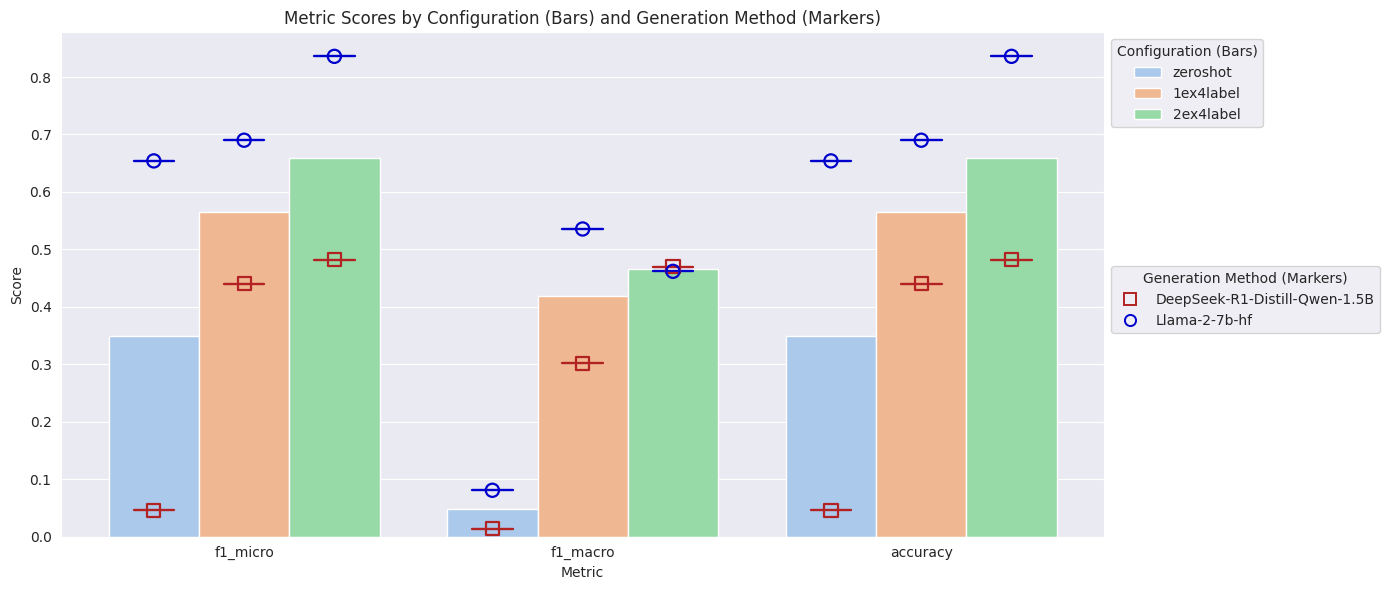

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# Set style
sns.set_style("darkgrid")


# Melt the data to long format
df_long = df_results.melt(
    id_vars=["method", "model"],
    value_vars=["f1_micro", "f1_macro", "accuracy"],
    var_name="metric",
    value_name="score"
)

# Set the figure
plt.figure(figsize=(14, 6))

# Create a grouped barplot
barplot = sns.barplot(
    data=df_long,
    x="metric",
    y="score",
    hue="method",
    errorbar=None,
    palette="pastel"
)

# Compute positions of bars to align dots
metric_order = df_long['metric'].unique()
config_order = df_long['method'].unique()
group_width = 0.8
n_configs = len(config_order)
bar_width = group_width / n_configs

# Compute x positions for bars
x_positions = {}
for i, metric in enumerate(metric_order):
    for j, config in enumerate(config_order):
        x = i - group_width/2 + j * bar_width + bar_width / 2
        x_positions[(metric, config)] = x

# Define marker styles for generation methods
marker_styles = {
    # 'real': ('d', 'black'),
    'DeepSeek-R1-Distill-Qwen-1.5B': ('s', 'firebrick'),
    'Llama-2-7b-hf': ('o', 'mediumblue'),
    # 'unsupContext': ('X', 'forestgreen'),
    # 'zeroshotLabel': ('^', 'orange')
}


# Only plot dots for selected generation methods
excluded_methods = ['real', 'zeroshotLabel']

for _, row in df_long.iterrows():
    if row['model'] in excluded_methods:
        continue  # skip plotting for real and zeroshotLabel

    x = x_positions[(row['metric'], row['method'])]
    marker, edge_color = marker_styles[row['model']]
    plt.scatter(
        x, row['score'],
        facecolors='none',
        edgecolors=edge_color,
        marker=marker,
        s=90,
        linewidth=1.6,
        zorder=5
    )
    tick_width = 0.06
    plt.plot([x - tick_width, x + tick_width], [row['score'], row['score']], color=edge_color, lw=1.7, zorder=4)


# Custom legend (excluding real and zeroshotLabel)
scatter_handles = [
    Line2D([0], [0], marker=m, color=c, label=label, markerfacecolor='none',
           markeredgewidth=1.4, markersize=8, linestyle='None')
    for label, (m, c) in marker_styles.items() if label not in excluded_methods
]


# Plot customization
plt.title("Metric Scores by Configuration (Bars) and Generation Method (Markers)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(ticks=range(len(metric_order)), labels=metric_order)

# Legends
bar_handles, bar_labels = barplot.get_legend_handles_labels()
legend1 = plt.legend(bar_handles, bar_labels, title='Configuration (Bars)', loc='upper left', bbox_to_anchor=(1, 1))
plt.legend(scatter_handles, marker_styles.keys(), title='Generation Method (Markers)', loc='upper left', bbox_to_anchor=(1, 0.55))
plt.gca().add_artist(legend1)

plt.tight_layout()
plt.show()
